In [1]:
import torch, torchvision
from torch.utils.data import DataLoader
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(torch.__version__)
print(device)

2.13.0+cu126
cuda


In [2]:
import torch
from torchvision import datasets, transforms
train_all = datasets.MNIST(root="data", train=True, download=True,
transform=transforms.ToTensor())   
print(len(train_all))               
x0, y0 = train_all[0]               
print(type(x0).__name__, y0)        
print(x0.shape)                     
# → 60000   (샘플 수)
# 전처리 등록
# 0번 샘플과 라벨
# → Tensor 5   (지난주엔 PIL 이미지였음)
# → torch.Size([1, 28, 28])   (채널이 맨 앞)
print(x0.min().item(), x0.max().item())   
# → 0.0 1.0   (스케일링 자동 적용)

60000
Tensor 5
torch.Size([1, 28, 28])
0.0 1.0


In [3]:
import torch
from torchvision import datasets, transforms
test = datasets.MNIST(root="data", train=False, download=True,
transform=transforms.ToTensor())    
print(len(test))                          
x, y = test[100]                          
print(x.shape, y)                         
print((test.targets[:1000] == 7).sum().item())   
# → 99

10000
torch.Size([1, 28, 28]) 6
99


In [4]:
import torch
from torchvision import datasets, transforms
train_all = datasets.MNIST(root="data", train=True, download=True,
transform=transforms.ToTensor())
x, y = train_all[59999]              
print(x.shape, y)                    
# → torch.Size([1, 28, 28]) 8
raw = datasets.MNIST(root="data", train=True, download=True)   
print(type(raw[0][0]).__name__)      

torch.Size([1, 28, 28]) 8
Image


In [5]:
import torch
from torchvision import datasets, transforms
train_all = datasets.MNIST(root="data", train=True, download=True,
transform=transforms.ToTensor())
from torch.utils.data import DataLoader
loader = DataLoader(train_all, batch_size=64, shuffle=True)   
print(len(loader))            
x, y = next(iter(loader))     
print(x.shape)                
print(y.shape)                
print(y[:8].tolist()) 

938
torch.Size([64, 1, 28, 28])
torch.Size([64])
[7, 4, 0, 3, 9, 5, 6, 1]


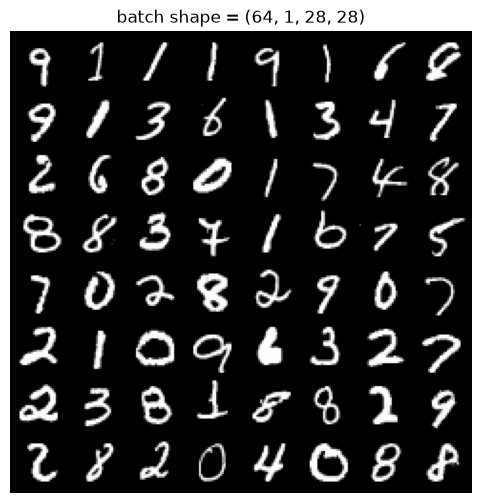

[9, 1, 1, 1, 9, 1, 6, 8]


In [6]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid       
x, y = next(iter(loader))                     
grid = make_grid(x, nrow=8)                   
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0))             
plt.title(f"batch shape = {tuple(x.shape)}"); plt.axis("off"); plt.show()
print(y[:8].tolist())  

In [17]:
import torch
from torchvision import datasets, transforms
train_all = datasets.MNIST(root="data", train=True, download=True,
transform=transforms.ToTensor())
from torch.utils.data import DataLoader, random_split
g = torch.Generator().manual_seed(0)             

train_set, val_set = random_split(train_all, [50000, 10000], generator=g)
print(len(train_set), len(val_set))              

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)    
val_loader = DataLoader(val_set, batch_size=256, shuffle=False)      
print(len(train_loader), len(val_loader))

50000 10000
782 40


In [18]:
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)

model = nn.Sequential(
    nn.Linear(784, 100), 
    nn.ReLU(),
    nn.Linear(100, 10)
).to(device)

opt = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(6):
    # 1. 학습 루프
    for x, y in train_loader:
        x, y = x.view(-1, 784).to(device), y.to(device)
        loss = loss_fn(model(x), y)
        opt.zero_grad()
        loss.backward()
        opt.step()
    
    # 2. 에폭마다 검증 수행 (for epoch 안쪽으로 들여쓰기)
    correct = 0                                     
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.view(-1, 784).to(device), y.to(device)
            correct += (model(x).argmax(dim=1) == y).sum().item()
            
    print(epoch + 1, round(correct / 10000 * 100, 1))

1 89.9
2 93.8
3 94.9
4 95.7
5 95.5
6 96.3
